# 01 — Dataset Overview

Goal: understand schema, join integrity, missing values, and the basic shape of every table before doing any analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
DATA = Path('../')

advertisers   = pd.read_csv(DATA / 'advertisers.csv')
campaigns     = pd.read_csv(DATA / 'campaigns.csv')
creatives     = pd.read_csv(DATA / 'creatives.csv')
daily         = pd.read_csv(DATA / 'creative_daily_country_os_stats.csv', parse_dates=['date'])
creative_sum  = pd.read_csv(DATA / 'creative_summary.csv')
campaign_sum  = pd.read_csv(DATA / 'campaign_summary.csv')

print('Loaded all tables.')

Loaded all tables.


## 1. Table Shapes & Memory

In [2]:
tables = {
    'advertisers': advertisers,
    'campaigns': campaigns,
    'creatives': creatives,
    'creative_daily_country_os_stats': daily,
    'creative_summary': creative_sum,
    'campaign_summary': campaign_sum,
}

summary = pd.DataFrame([
    {'table': name, 'rows': df.shape[0], 'cols': df.shape[1],
     'memory_MB': round(df.memory_usage(deep=True).sum() / 1e6, 2)}
    for name, df in tables.items()
])
print(summary.to_string(index=False))

                          table   rows  cols  memory_MB
                    advertisers     36     4       0.01
                      campaigns    180    14       0.12
                      creatives   1080    32       1.07
creative_daily_country_os_stats 192315    14      38.66
               creative_summary   1080    59       1.36
               campaign_summary    180    22       0.13


## 2. Missing Values

In [3]:
def null_summary(df, name):
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print(f'{name}: no nulls')
    else:
        print(f'\n{name}:')
        print((nulls / len(df) * 100).round(1).rename('null_%').to_frame())

for name, df in tables.items():
    null_summary(df, name)

advertisers: no nulls
campaigns: no nulls
creatives: no nulls
creative_daily_country_os_stats: no nulls

creative_summary:
             null_%
fatigue_day    81.6
campaign_summary: no nulls


**Note:** `fatigue_day` is intentionally null for non-fatigued creatives — this is by design, not a data quality issue.

## 3. Join Integrity

In [4]:
print('=== Advertiser-level ===')
print(f'Unique advertisers:        {advertisers.advertiser_id.nunique()}')
print(f'Campaigns per advertiser:  {campaigns.groupby("advertiser_id").size().describe()[["min","max","mean"]]}')

print('\n=== Campaign-level ===')
print(f'Unique campaigns:          {campaigns.campaign_id.nunique()}')
print(f'Creatives per campaign:    {creatives.groupby("campaign_id").size().describe()[["min","max","mean"]]}')

print('\n=== Creative-level ===')
print(f'Unique creatives:          {creatives.creative_id.nunique()}')
print(f'Expected (36×5×6):         1080')

print('\n=== Daily stats ===')
print(f'Unique creatives in daily: {daily.creative_id.nunique()}')
print(f'Date range: {daily.date.min().date()} → {daily.date.max().date()}')
print(f'Countries: {daily.country.nunique()}, OS values: {daily.os.nunique()}')

=== Advertiser-level ===
Unique advertisers:        36
Campaigns per advertiser:  min     5.0
max     5.0
mean    5.0
dtype: float64

=== Campaign-level ===
Unique campaigns:          180
Creatives per campaign:    min     6.0
max     6.0
mean    6.0
dtype: float64

=== Creative-level ===
Unique creatives:          1080
Expected (36×5×6):         1080

=== Daily stats ===
Unique creatives in daily: 1080
Date range: 2026-01-01 → 2026-03-16
Countries: 10, OS values: 2


## 4. Dimension Distributions

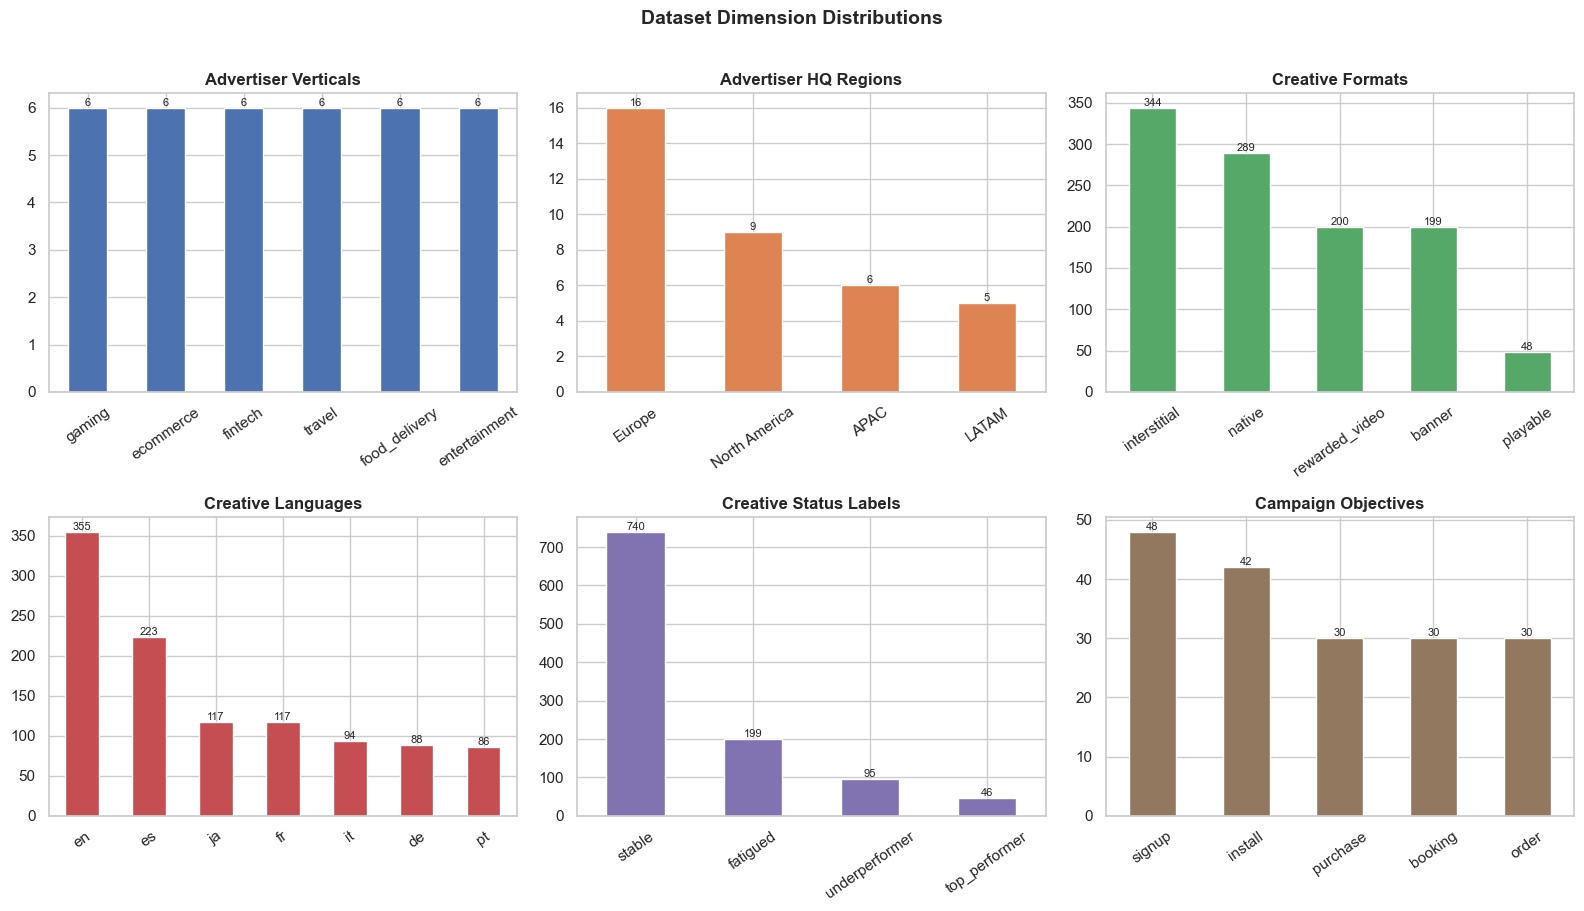

Saved: 01_dimension_distributions.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

def bar(ax, series, title, color='steelblue'):
    vc = series.value_counts()
    vc.plot.bar(ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
    for p in ax.patches:
        ax.annotate(str(int(p.get_height())),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

bar(axes[0,0], advertisers['vertical'],      'Advertiser Verticals',     '#4C72B0')
bar(axes[0,1], advertisers['hq_region'],     'Advertiser HQ Regions',    '#DD8452')
bar(axes[0,2], creatives['format'],          'Creative Formats',         '#55A868')
bar(axes[1,0], creatives['language'],        'Creative Languages',       '#C44E52')
bar(axes[1,1], creative_sum['creative_status'], 'Creative Status Labels', '#8172B2')
bar(axes[1,2], campaigns['objective'],       'Campaign Objectives',      '#937860')

plt.suptitle('Dataset Dimension Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5. Date Coverage & Daily Volume

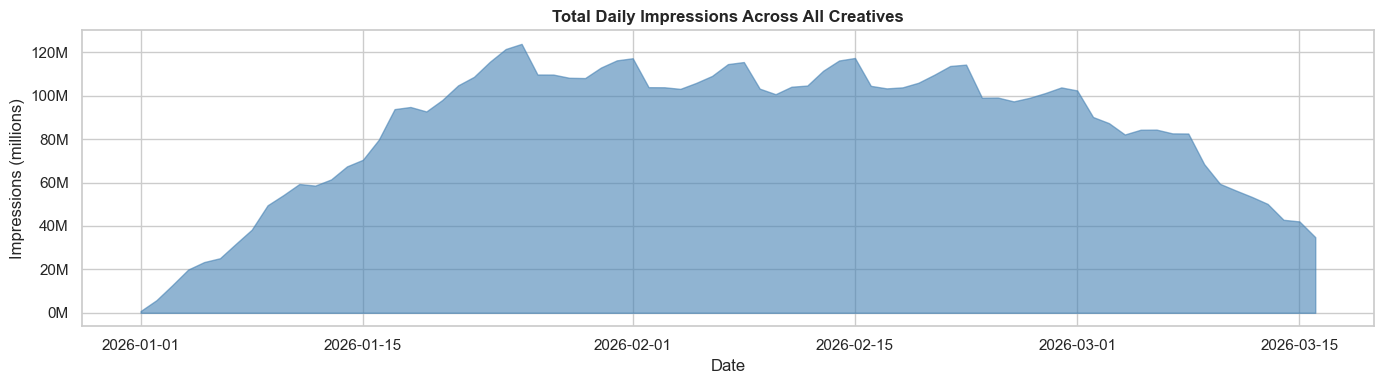

In [6]:
daily_volume = daily.groupby('date')['impressions'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(daily_volume['date'], daily_volume['impressions'] / 1e6, alpha=0.6, color='steelblue')
ax.set_title('Total Daily Impressions Across All Creatives', fontweight='bold')
ax.set_ylabel('Impressions (millions)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
plt.tight_layout()
plt.show()

## 6. Portfolio Uniformity Check

In [7]:
camps_per_adv = campaigns.groupby('advertiser_id').size()
creatives_per_camp = creatives.groupby('campaign_id').size()

print('Campaigns per advertiser — unique values:', camps_per_adv.unique())
print('Creatives per campaign  — unique values:', creatives_per_camp.unique())
print()
print('Portfolio is perfectly uniform: every advertiser has 5 campaigns,'
      ' every campaign has 6 creatives.')
print('Avoid "most active" analyses — they will always tie.')
print('Focus on PERFORMANCE metrics instead.')

Campaigns per advertiser — unique values: [5]
Creatives per campaign  — unique values: [6]

Portfolio is perfectly uniform: every advertiser has 5 campaigns, every campaign has 6 creatives.
Avoid "most active" analyses — they will always tie.
Focus on PERFORMANCE metrics instead.


## 7. Numeric Summary of creative_summary

In [8]:
kpi_cols = ['overall_ctr', 'overall_cvr', 'overall_roas', 'overall_ipm',
            'ctr_decay_pct', 'cvr_decay_pct', 'perf_score', 'total_spend_usd',
            'total_impressions', 'total_days_active']
creative_sum[kpi_cols].describe().round(3)

,overall_ctr,overall_cvr,overall_roas,overall_ipm,ctr_decay_pct,cvr_decay_pct,perf_score,total_spend_usd,total_impressions,total_days_active
count,1080.000,1080.000,1080.000,1080.000,1080.000,1080.000,1080.000,1080.000,1.080000e+03,1080.000
mean,0.005,0.098,3.635,0.567,-0.781,-0.067,0.500,29628.585,5.895829e+06,48.471
std,0.002,0.047,2.690,0.462,0.071,0.096,0.191,13622.962,3.492825e+06,8.873
min,0.002,0.041,0.673,0.126,-0.900,-0.450,0.009,8248.880,1.012224e+06,28.000
25%,0.004,0.063,1.685,0.308,-0.832,-0.124,0.357,20131.082,3.540058e+06,42.000
50%,0.005,0.089,2.326,0.404,-0.795,-0.068,0.512,26638.040,5.027634e+06,48.000
75%,0.006,0.104,5.642,0.570,-0.740,-0.012,0.647,36083.805,7.274785e+06,55.000
max,0.014,0.241,13.392,3.085,-0.477,0.338,0.935,106633.220,3.391405e+07,74.000


## 8. Design Score Summary

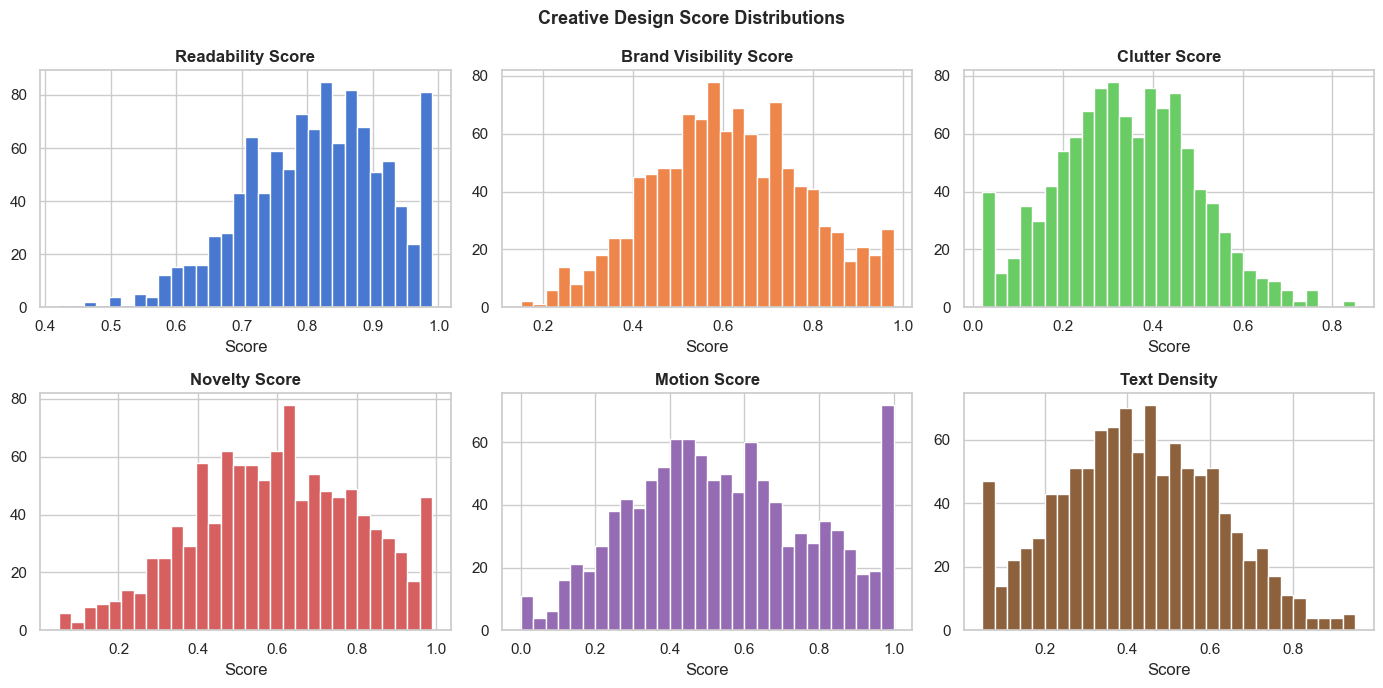

In [9]:
design_cols = ['readability_score', 'brand_visibility_score', 'clutter_score',
               'novelty_score', 'motion_score', 'text_density']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
colors = sns.color_palette('muted', 6)

for i, col in enumerate(design_cols):
    axes[i].hist(creatives[col].dropna(), bins=30, color=colors[i], edgecolor='white')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_xlabel('Score')

plt.suptitle('Creative Design Score Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()